# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">How to Handle Textual Data in NLP</p>

***In this notebook, I aim to provide insights into "How to Handle Textual Data in NLP". I will cover two major aspects:***

***1. Text Preprocessing:***
***I will demonstrate how to preprocess textual data using a real-world dataset, specifically the "IMDB-Movies" dataset. My primary focus is to simplify and illustrate text preprocessing techniques. However, if you encounter any difficulties, please feel free to comment, and I will do my best to address them.***

***2. Text Representation:***
***Text representation involves converting textual data into numerical format. I will discuss some of the most important techniques for handling textual data in machine learning, including:***
   1. One-Hot Encoding (OHE)
   2. Bag of Words
   3. N-grams
   4. TF-IDF
   
***I will provide demonstrations of how these four techniques work on the original dataset.***

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#F52549;">About Author!</p>
##### ***Hello, I'm  Muhammad_Abdullah : A Data Science Enthusiast and Kaggle 2x Expert***

Greetings! I'm delighted to welcome you into my world of data science exploration and innovation. I'm **Muhammad_Abdullah**, a passionate data scientist with a fervent dedication to unraveling the mysteries hidden within datasets and leveraging the power of machine learning to drive meaningful insights and solutions.

###### ***A Passion for Data Science***

Since the inception of my journey into the captivating realm of data science, I've been driven by an insatiable curiosity and an unwavering passion for uncovering the stories embedded in data. From the thrill of diving deep into complex datasets to the exhilaration of crafting predictive models that shape our understanding of the world, data science has become not just a profession but a lifelong passion.

###### ***Guiding Light on Kaggle***

As a Kaggle 2x Expert, I've had the privilege of sharing my knowledge, insights, and experiences with the vibrant Kaggle community. Through meticulously crafted notebooks, engaging discussions, and collaborative projects, I've had the opportunity to mentor aspiring data enthusiasts, foster a culture of learning and growth, and contribute to the collective pursuit of excellence in data science.

###### ***Let's Explore Together***

Join me on an exhilarating adventure into the dynamic world of data science! Together, we'll unlock the potential of data, unravel its mysteries, and embark on a transformative journey of discovery and innovation. Whether you're a seasoned data enthusiast or just beginning your data science odyssey, I'm excited to share this journey with you and explore the endless possibilities that data science has to offer.
<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Website</b></th>
            <th><b>Links</b></th>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/muhammadabdullah0303"><img src="https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/muhammad-abdullah-6b84b4297/"><img src="https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>Facebook</td>
            <td><a href="https://web.facebook.com/abd.sentaflexmental"><img src="https://img.shields.io/badge/Facebook-Profile-blue?style=for-the-badge&logo=facebook" alt="Facebook"/></a></td>
        </tr>
        <tr>
            <td>Gmail</td>
            <td><a href="mailto:mrabdullah@gmail.com"><img src="https://img.shields.io/badge/Gmail-Contact%20Me-red?style=for-the-badge&logo=gmail" alt="Gmail"/></a></td>
        </tr>
    </table>
</div>


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">Basis Libraries</p>

In [ ]:
# Punctuations
import string
# Pandas
import pandas as pd
# Remove Stopwords
from nltk.corpus import stopwords 
# Regular Expressions
import re
# Import PorterStemmer from NLTK Library
from nltk.stem.porter import PorterStemmer
# Lemmatization
from nltk.stem import WordNetLemmatizer
# Tokenization
from nltk.tokenize import word_tokenize
# Imporr Ohe 
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">Loading Data </p>

In [ ]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

In [ ]:
# Head 
df.head()

In [ ]:
# Null Values
df.isnull().sum()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1. Basis Text Preprocessing</p>

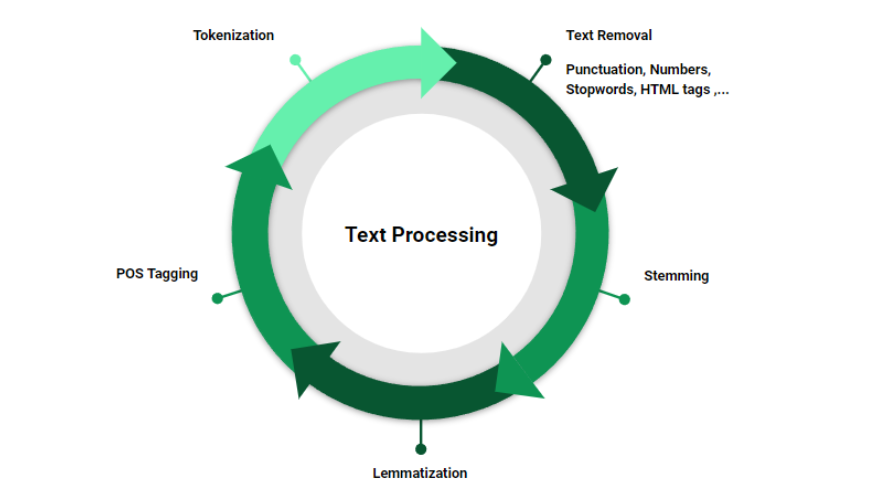

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.1 LowerCasing</p>


In [ ]:
# Lowercase All The Text
df['review'] = df['review'].str.lower()

# Head 
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.2 Removing Punctuations</p>


In [ ]:
# Removing Punctuations
df['review'] = df['review'].str.translate(str.maketrans('', '', string.punctuation))

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.3 Removing StopWords</p>

In [ ]:
# Intilize Stopwords
stop_words = stopwords.words('english')

# Apply Stopwords
df['review'] = df['review'].apply(lambda x : ' '.join([word for word in x.split() if word not in (stop_words)]))
# Head 
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.4 Removing HTMl Tags</p>

In [ ]:
# Function to remove HTML Tags
def remove_tags(text):
    return re.sub('<[^<]+?>', '', text)

# Calling Function
df['review'] = df['review'].apply(remove_tags)

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.5 Removing URLs</p>

In [ ]:
# Remove URLS
df['review'] = df['review'].str.replace('http\S+|www.\S+', '', case=False)

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.6 Handling ChatsWords</p>

In [ ]:
# Here Come ChatWords Which i Get from a Github Repository
# Repository Link : https://github.com/rishabhverma17/sms_slang_translator/blob/master/slang.txt
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [ ]:
# Function
def chat_conversion(text):
    new_text = []
    for i in text.split():
        if i.upper() in chat_words:
            new_text.append(chat_words[i.upper()])
        else:
            new_text.append(i)
    return " ".join(new_text)

# Calling Function 
df['review'] = df['review'].apply(chat_conversion)

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.7 Word_Tokenization</p>


In [ ]:
# Tokenization 
from nltk.tokenize import word_tokenize

# Apply word_tokenize
df['review_word_token'] = df['review'].apply(word_tokenize)

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.8 Sentence_Tokenization</p>


In [ ]:
# Tokenization 
from nltk.tokenize import sent_tokenize

# Apply sent_tokenize
df['review_sent_token'] = df['review'].apply(sent_tokenize)

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.9 Stemming</p>


In [ ]:
# Intlize PorterStemmer
ps = PorterStemmer()

# Apply PorterStemmer
df['review_stemmed'] = df['review'].apply(lambda x: ' '.join([ps.stem(word) for word in x.split()]))

# Head
df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">1.10 Lemmatization</p>


In [ ]:
# Download NLTK resources (uncomment the following line if not already downloaded)?
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [ ]:
# # Intilize Lemmatizer
# wordnet_lemmatizer = WordNetLemmatizer()

# # Apply 
# df['review_lemmatized'] = df['review'].apply(lambda x: ' '.join([wordnet_lemmatizer.lemmatize(word , pos='v') for word in x.split()]))

# # Head
# df.head()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">2. Text Representation</p>


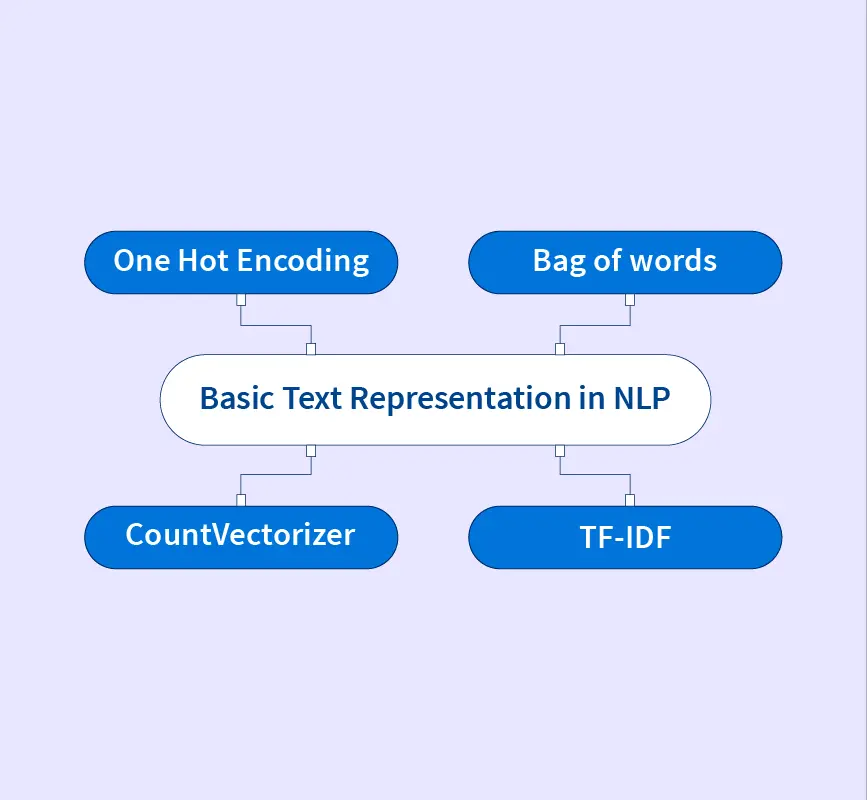

### ***1. What is Feature Extraction from Text?***
***Feature extraction from text refers to the process of converting textual data into numerical representations. It's also known as text representation or text vectorization.***

### ***2. Why Do We Need It?***
***In natural language processing (NLP) tasks using machine learning, providing effective features to models is crucial. Text vectorization is a pivotal step in ML-based NLP, facilitating the transformation of text data into a format suitable for modeling.***

### ***3. Why Is It Difficult?***
***While it's straightforward to represent data like pixels in images or audio in numerical form, converting text into meaningful numerical representations poses challenges. Text carries rich semantic meaning, and preserving this meaning during conversion is complex.***

###***4. What Is the Core Idea?***
***The core idea of text-to-number conversion is to encode the semantic meaning of the text into numerical representations effectively.***

### ***5. What Are the Techniques?***
***a. One-Hot Encoding (OHE): Assigning a unique binary value to each word in the vocabulary.***

***b. Bag of Words (BOW): Representing text as a frequency distribution of words, disregarding grammar and word order.***

***c. N-Grams: Capturing the co-occurrence of adjacent words by considering sequences of n words.***

***d. Term Frequency-Inverse Document Frequency (TF-IDF): Weighing the importance of words in a document relative to their frequency across the corpus.***

### ***Some Common Terms***
#### a. ***Corpus: The entire collection of text data, comprising all documents or texts under consideration.***

#### b. ***Vocabulary: The set of unique words present in the corpus.***

#### c. ***Document: Each individual piece of text in the corpus, such as a review, article, or sentence.***

#### d. ***Word: The basic unit of textual data, representing a single element of meaning.***

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">Corpus</p>

In [ ]:
# First of all we made a corpus of All words 
corpus = []

# Run a Loop and Append Reviews in corpus
for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['review_stemmed'][i])
    review = review.split()
    review = ' '.join(review)
    corpus.append(review)

In [ ]:
# Len Of Corpus
print(f'The Lenght of the Corpus is : {len(corpus)}')

In [ ]:
# Total number of words in corpus
# Initialize total_words counter
total_words = 0

# Iterate through each element in the corpus list
for text in corpus:
    # Split the text into words and update the total_words counter
    total_words += len(text.split())

# Print the total number of words
print(f"Total words in Corpus is : {total_words}")

In [ ]:
# head
corpus[0]

In [ ]:
corpus[11]

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">Vocabulary</p>


In [ ]:
# Let's find the unique words in the corpus
vocabulary = set()

# Apply vocabulary
for review in corpus:
    # Split the review into words
    words = review.split()
    # Update the vocabulary set with unique words from the review
    vocabulary.update(words)

# Convert the set back to a list if needed
vocabulary = list(vocabulary)

In [ ]:
# Lenght of Vocab
print(f'The Lenght of the Vocabulary  is : {len(vocabulary)}')

In [ ]:
# Head of Vocab
vocabulary[0:10]

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">2.1 OneHotEncoding Text</p>


***In natural language processing (NLP), one-hot encoding (OHE) is a technique used to represent categorical data, such as words or phrases, in a binary format. Each word in a vocabulary is assigned a unique binary vector, where only one bit is set to 1 (indicating the presence of the word) and the rest are set to 0.***

In [ ]:
vocabulary_short = vocabulary[0:20000]

In [ ]:
# Lenght of Vocab
print(f'The Lenght of the Vocabulary  is : {len(vocabulary_short)}')

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create a tokenizer object with the desired maximum number of words
tokenizer = Tokenizer(num_words=20000)  # Adjust the value as needed

# Fit tokenizer on vocabulary_short to build the vocabulary
tokenizer.fit_on_texts(vocabulary_short)

# One-hot encode the text data
one_hot_encoded = tokenizer.texts_to_matrix(vocabulary_short, mode='binary')

# Print the one-hot encoded representation
print(one_hot_encoded)

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">2.2 Bag of Words BOW</p>


***Bag of Words (BoW) is a well-known and widely used technique in text classification, despite its age. Its effectiveness lies in its simplicity and ability to handle out-of-vocabulary (OOV) words.***
### ***2. Working***
***Here's how it works: first, we create a vocabulary from our corpus, typically represented by a fixed number of words, let's say 5. Then, for each document, we count how many times each word from the vocabulary occurs. The order of words doesn't matter in BoW.***
### ***3. Core Idea***
***The core idea behind BoW is that it focuses on word frequency rather than context. It assumes that documents with similar content will have similar word frequencies. In other words, if two documents belong to the same category, they are likely to have similar word frequencies.***
### ***4. How we Capture Semmentic Meaning of Words***
***However, BoW doesn't capture contextual or semantic meaning directly. It treats text as a vector in a high-dimensional space, with each dimension representing a word from the vocabulary. Documents are then compared based on the angle between their vectors. Similar documents will have smaller angles between their vectors, indicating similar word frequencies.***
### ***5. Summarization***
***One advantage of BoW is its ability to handle OOV words, as it only relies on the presence or absence of words in the vocabulary.In summary, BoW is a simple yet effective technique for text classification, focusing on word frequency rather than context or meaning.It represents text as vectors in a high-dimensional space and compares documents based on the angle between their vectors.***

### ***Code Working***

1. **Initializing CountVectorizer**:
   - `cv = CountVectorizer(max_features=10000)`: Here, an instance of the `CountVectorizer` class is created with a parameter `max_features` set to 10000. 
     - `max_features` specifies the maximum number of features (words or tokens) to consider based on their frequency. In this case, it limits the vocabulary to the top 10,000 most frequent words in the corpus.

2. **Fitting the Data**:
   - `bow = cv.fit_transform(df['review_lemmatized'])`: This line fits the `CountVectorizer` to the text data and transforms the text data into a document-term matrix.
     - `df['review_lemmatized']` is assumed to be a Pandas DataFrame column containing preprocessed and lemmatized text data (e.g., reviews).
     - The `fit_transform()` method first fits the `CountVectorizer` to learn the vocabulary from the text data (`df['review_lemmatized']`) and then transforms the text data into a sparse matrix where each row represents a document (review) and each column represents a token (word). The values in the matrix indicate the count of each token in the corresponding document.

In summary, this code segment imports the `CountVectorizer` class, initializes it with a maximum feature limit of 10,000, and then fits it to the lemmatized text data to create a document-term matrix representing the word counts in each document.

In [ ]:
# import 
from sklearn.feature_extraction.text import CountVectorizer

# Intilize 
cv = CountVectorizer(max_features=10000) # Adjust the Value as needed 

# Fit on Data 
bow = cv.fit_transform(df['review_stemmed'])

In [ ]:
# # Show Vocabulary 
print(f'The lenght of the Vocabulary Generated by Bag of Words is : {len(cv.vocabulary_)}')

In [ ]:
# Enocded Sequence from Data 
bow[0].toarray()

In [ ]:
# Number of times each word has occurred
word_counts = bow.toarray().sum(axis=0)
word_counts

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">2.3 Bi-Gram and Tri-Gram</p>

***This technique is quite similar to BOW, but with a key difference. Instead of considering single words as vocabulary units, N-grams generate multiple word combinations. For example, in Bi-grams, we pair two words as vocabulary units, while Tri-grams use three-word combinations.***

### ***3. Advantages:***
1. ***Able to capture semantic meanings.***
2. ***Simple and intuitive.***

### ***4. Disadvantages:***
1. ***Increased vocabulary dimensionality in Bi-grams and Tri-grams can lead to longer training times with large datasets.***
2. ***No perfect solution for Out-Of-Vocabulary (OOV) words.***

### ***Code Working***

1. `cv_bi = CountVectorizer(max_features=10000, ngram_range=(2,2))`:
   - Here, `CountVectorizer` is a method from the scikit-learn library used for converting a collection of text documents into a matrix of token counts.
   - `max_features=10000` specifies that we want to limit the number of features (words or tokens) to the top 10,000 most frequent ones. This parameter helps in managing the memory and processing time, especially for large datasets.
   - `ngram_range=(2,2)` specifies that we want to create bigrams, which are sequences of two adjacent words (bi-grams) in the text. This means that the CountVectorizer will consider pairs of consecutive words as features in addition to single words.

2. `bow_bi = cv_bi.fit_transform(df['review_lemmatized'])`:
   - `cv_bi.fit_transform()` is a method that fits the CountVectorizer to the text data and transforms the text data into a document-term matrix.
   - `df['review_lemmatized']` is assumed to be a Pandas DataFrame column containing preprocessed and lemmatized text data (e.g., reviews).
   - The `fit_transform()` method first fits the CountVectorizer to learn the vocabulary from the text data (`df['review_lemmatized']`) and then transforms the text data into a sparse matrix where each row represents a document (review) and each column represents a token (word or bigram). The values in the matrix indicate the count of each token in the corresponding document.

In summary, this code snippet initializes a CountVectorizer object to create a document-term matrix considering `bigrams` (pairs of consecutive words) as features and limits the vocabulary to the top 10,000 most frequent tokens. Then, it fits the CountVectorizer to the lemmatized text data and transforms the data into a sparse matrix representation.

In [ ]:
# Bigram 
cv_bi = CountVectorizer(max_features=10000 , ngram_range=(2,2))

# Fitting
bow_bi = cv_bi.fit_transform(df['review_stemmed'])

In [ ]:
# Vocabulary of bi-grams
bi_gram_vocabulary = cv_bi.get_feature_names_out()

# Length
print(f'The lenght of the Vocabulary Generated by Bag of Words Bi Gram  is : {len(bi_gram_vocabulary)}')

In [ ]:
# Number of times each word has occurred
word_counts = bow_bi.toarray().sum(axis=0)
word_counts

---


### ***Code Working***

1. `cv_tri = CountVectorizer(ngram_range=(3,3))`:
   - Similar to the previous code, `CountVectorizer` is used to convert text data into a matrix of token counts.
   - `ngram_range=(3,3)` specifies that we want to create **Trigrams**, which are sequences of three adjacent words (tri-grams) in the text. This means that the CountVectorizer will consider triplets of consecutive words as features in addition to single words.

2. We do she same process as we do above. 

In summary, this code initializes a CountVectorizer object to create a document-term matrix considering trigrams (triplets of consecutive words) as features. Then, it fits the CountVectorizer to the lemmatized text data and transforms the data into a sparse matrix representation.

In [ ]:
# Tri Gram 
cv_tri = CountVectorizer(max_features=10000,ngram_range=(3,3))

# Fitting 
bow_tri = cv_tri.fit_transform(df['review_stemmed'])

In [ ]:
# Vocabulary of bi-grams
tri_gram_vocabulary = cv_tri.get_feature_names_out()

# Length
print(f'The lenght of the Vocabulary Generated by Bag of Words Tri Gram  is : {len(tri_gram_vocabulary)}')

In [ ]:
# Number of times each word has occurred
word_counts = bow_tri.toarray().sum(axis=0)
word_counts

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">2.4 TF_IDF</p>

### ***TF-IDF (Term Frequency-Inverse Document Frequency)***
***TF-IDF (Term Frequency-Inverse Document Frequency) assigns different values to words in a vocabulary based on their importance in documents. It operates on a simple principle: if a word appears frequently in a particular document but rarely across the entire corpus, it's considered significant for that document, thus receiving a higher weight.***
 
### ***To calculate these values, TF-IDF uses two terms:***
1. ***TF (Term Frequency): The frequency of a term in a document, normalized between 0 and 1, indicating the probability of that term occurring in the document.***
   ***Formula: TF(t,d) = Number of Occurrences of Term t in Document d / Total Number of Terms in Document d***
 
2. ***IDF (Inverse Document Frequency): Measures how rare a term is across the entire corpus.***
   ***Formula: IDF = Total Number of Documents in Corpus / Number of Documents with Term t***

***So the idea is that , if the word is frequent in the corpus , THE idf value will be very low , If the word is rare in the document the idf wil be high .***

In [ ]:
# Import 
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Intilize 
tf_idf = TfidfVectorizer()

# Fitting
tf = tf_idf.fit_transform(df['review_stemmed'])

In [ ]:
# Len of Vocabulary
print(f"The Lenght of Tf-idf Vocabulary is {len(tf_idf.vocabulary_)}")

In [ ]:
# Some Random Text 
tf[120].toarray()

In [ ]:
# IDF scores of words
idf_scores = tf_idf.idf_

# Print the IDF scores of words and the vocabulary
print("IDF Scores of Words:", idf_scores)

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#F52549;">The End</p>


```***Hope you like the setup! If you encounter any issues or have questions, feel free to comment below. I'll do my best to provide clear and helpful answers.***```